# 🖐️ Palmprint Recognition — HOG-SGF + PCA + Cosine Similarity
**Revisi Dosen:**
- ✅ Threshold optimal (sweep F1-Score terbaik, bukan auto-percentile)
- ✅ PCA variance otomatis (95%)
- ✅ Palm detector pakai OpenCV (bukan YOLO)
- ✅ Hyperparameter tuning (default dulu, uncomment untuk eksplorasi)

---

## Cell 1 — Import & Konfigurasi

In [8]:
import os
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from skimage.feature import hog
import warnings
from roi_mediapipe import detect_palm_opencv
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# KONFIGURASI DEFAULT
# ─────────────────────────────────────────────

class Config:
    DATASET_PATH   = r'D:\xampp\htdocs\palmprint-backend\palmprint-ml\dataset'
    OUTPUT_PATH    = 'results'
    MODELS_DIR     = 'models'

    # ROI
    ROI_SIZE       = 200
    IMAGE_SIZE     = 64        # paper: 64×64

    # HOG — default (akan di-tuning)
    HOG_ORIENT     = 6
    HOG_PIXELS     = 16        # pixels per cell
    HOG_CELLS      = 2         # cells per block

    # SGF — 24 orientasi (0°–345°, step 15°)
    SGF_ANGLES     = np.deg2rad(np.arange(0, 360, 15))

    # CLAHE
    CLAHE_CLIP     = 2.0
    CLAHE_TILE     = (8, 8)

    # Gabor
    GABOR_KSIZE    = 21
    GABOR_SIGMA    = 4.0
    GABOR_LAMBDA   = 10.0
    GABOR_GAMMA    = 0.5
    GABOR_THETAS   = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    # PCA — variance otomatis
    PCA_VARIANCE   = 0.99     

    # Skin detection (OpenCV)
    SKIN_LOWER_YCR = np.array([0,  133, 77],  dtype=np.uint8)
    SKIN_UPPER_YCR = np.array([255, 173, 127], dtype=np.uint8)

for d in [Config.OUTPUT_PATH, Config.MODELS_DIR]:
    os.makedirs(d, exist_ok=True)

print('✓ Import selesai')
print(f'  Dataset : {Config.DATASET_PATH}')
print(f'  PCA     : {int(Config.PCA_VARIANCE*100)}% variance otomatis')
print(f'  HOG     : orient={Config.HOG_ORIENT}, cell={Config.HOG_PIXELS}px, block={Config.HOG_CELLS}cells')

✓ Import selesai
  Dataset : D:\xampp\htdocs\palmprint-backend\palmprint-ml\dataset
  PCA     : 99% variance otomatis
  HOG     : orient=6, cell=16px, block=2cells


## Cell 2 — OpenCV Palm Detector (dengan Visualisasi)

In [9]:
# ═══════════════════════════════════════════════════════════════════
# [BARU - FASE 1B] ILLUMINATION NORMALIZATION
# ═══════════════════════════════════════════════════════════════════
 
def normalize_illumination(img_gray):
    """
    Normalisasi pencahayaan menggunakan DoG (Difference of Gaussians).
 
    Masalah yang diselesaikan:
      Foto dari HP punya variasi brightness yang beragam — terang, gelap,
      ada bayangan di tangan. Gabor filter akan menghasilkan respons berbeda
      untuk foto yang sama tapi pencahayaannya beda, padahal polanya sama.
 
    Cara kerja DoG:
      1. Blur gambar dengan Gaussian kecil (σ=1) → menangkap detail + cahaya
      2. Blur gambar dengan Gaussian besar (σ=10) → menangkap cahaya global saja
      3. Selisih keduanya = tekstur murni, bebas dari pencahayaan global
 
      DoG = G(σ=1) - G(σ=10)
 
    Kenapa DoG lebih baik dari CLAHE saja:
      CLAHE meningkatkan kontras lokal tapi tidak menghilangkan variasi
      pencahayaan global (tangan terang vs gelap tetap beda).
      DoG benar-benar memisahkan pencahayaan dari tekstur.
 
    Kenapa σ=1 dan σ=10:
      σ=1  → tangkap detail halus (lebar blur ~3px, cukup untuk palmprint)
      σ=10 → tangkap iluminasi global (lebar blur ~30px, smoothing besar)
      Selisih keduanya = band-pass filter yang menyisakan tekstur skala menengah
 
    Args:
        img_gray: grayscale image (np.uint8)
 
    Returns:
        normalized (np.uint8): gambar dengan pencahayaan ternormalisasi,
                               range 0-255, siap masuk Gabor filter
    """
    img_f = img_gray.astype(np.float32)
 
    # Gaussian blur kecil — tangkap detail + sedikit cahaya
    g_small = cv2.GaussianBlur(img_f, (0, 0), sigmaX=1.0)
 
    # Gaussian blur besar — tangkap pencahayaan global saja
    g_large = cv2.GaussianBlur(img_f, (0, 0), sigmaX=10.0)
 
    # DoG = selisih → tekstur murni (bisa negatif)
    dog = g_small - g_large
 
    # Normalize ke 0-255 untuk input Gabor
    normalized = cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
 
    return normalized
 

## Cell 3 — Gabor + CLAHE Enhancement (Visualisasi)

In [10]:
def enhance_gabor(img_gray, ksize=None, sigma=None, lambd=None, gamma=None, thetas=None, use_dog=False):
    """
    Gabor filter bank multi-orientasi + CLAHE.
    Parameter bisa di-override untuk tuning.
    """
    ksize  = ksize  or Config.GABOR_KSIZE
    sigma  = sigma  or Config.GABOR_SIGMA
    lambd  = lambd  or Config.GABOR_LAMBDA
    gamma  = gamma  or Config.GABOR_GAMMA
    thetas = thetas or Config.GABOR_THETAS
    
    if use_dog:
        img_gray = normalize_illumination(img_gray)
        
    responses = []
    for theta in thetas:
        kernel = cv2.getGaborKernel(
            ksize=(ksize, ksize), sigma=sigma, theta=theta,
            lambd=lambd, gamma=gamma, psi=0, ktype=cv2.CV_32F
        )
        resp = cv2.filter2D(img_gray.astype(np.float32), cv2.CV_32F, kernel)
        responses.append(np.abs(resp))

    gabor_max = np.max(responses, axis=0)
    gabor_max = cv2.normalize(gabor_max, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe     = cv2.createCLAHE(clipLimit=Config.CLAHE_CLIP, tileGridSize=Config.CLAHE_TILE)
    return clahe.apply(gabor_max)


In [11]:
def augment_roi(roi_gray):
    """
    Augmentasi ROI palmprint untuk training.
    Menghasilkan N_AUG variasi dari satu ROI.
 
    Augmentasi yang DIPILIH (aman untuk palmprint):
      1. Brightness shift     — simulasi variasi pencahayaan HP
      2. Gaussian noise       — simulasi noise sensor kamera
      3. Gaussian blur ringan — simulasi slight blur kamera HP
      4. Rotasi kecil ±10°   — toleransi sisa error alignment
      5. Random crop kecil   — toleransi pergeseran centroid ±15px
 
    Augmentasi yang DIHINDARI:
      - Horizontal/vertical flip → garis tangan kiri ≠ kanan
      - Rotasi besar >20°        → sudah ditangani alignment
      - Elastic distortion       → merusak struktur garis palmprint
      - Color jitter             → sudah grayscale
 
    Args:
        roi_gray: grayscale ROI ukuran ROI_SIZE x ROI_SIZE (np.uint8)
 
    Returns:
        augmented (list of np.uint8): list ROI hasil augmentasi
                                     TIDAK termasuk original
    """
    N_AUG   = 3      # jumlah augmentasi per gambar (total dataset = 4x)
    h, w    = roi_gray.shape[:2]
    results = []
 
    for _ in range(N_AUG):
        aug = roi_gray.copy().astype(np.float32)
 
        # ── 1. Brightness shift (50% chance) ──
        # Geser brightness ±30 untuk simulasi variasi cahaya
        if np.random.random() < 0.5:
            delta = np.random.uniform(-30, 30)
            aug   = np.clip(aug + delta, 0, 255)
 
        # ── 2. Contrast scaling (40% chance) ──
        # Scale kontras 0.8-1.2x untuk variasi exposure
        if np.random.random() < 0.4:
            alpha = np.random.uniform(0.8, 1.2)
            aug   = np.clip(aug * alpha, 0, 255)
 
        # ── 3. Gaussian noise (50% chance) ──
        # Tambah noise ringan σ=5-15 untuk simulasi sensor kamera HP
        if np.random.random() < 0.5:
            sigma = np.random.uniform(5, 15)
            noise = np.random.normal(0, sigma, aug.shape)
            aug   = np.clip(aug + noise, 0, 255)
 
        # ── 4. Gaussian blur ringan (40% chance) ──
        # Blur σ=0.5-1.5 untuk simulasi slight defocus kamera HP
        if np.random.random() < 0.4:
            sigma = np.random.uniform(0.5, 1.5)
            aug   = cv2.GaussianBlur(aug, (0, 0), sigma)
 
        # ── 5. Rotasi kecil ±10° (60% chance) ──
        # Toleransi sisa error dari alignment
        if np.random.random() < 0.6:
            angle  = np.random.uniform(-10, 10)
            center = (w // 2, h // 2)
            M      = cv2.getRotationMatrix2D(center, angle, 1.0)
            aug    = cv2.warpAffine(
                aug, M, (w, h),
                flags      = cv2.INTER_LINEAR,
                borderMode = cv2.BORDER_REFLECT  # reflect agar tidak ada border hitam
            )
 
        # ── 6. Random crop + resize (50% chance) ──
        # Crop ±15px dari tiap sisi, resize balik ke ROI_SIZE
        # Simulasi pergeseran centroid yang tidak sempurna
        if np.random.random() < 0.5:
            margin = 15
            x1 = np.random.randint(0, margin)
            y1 = np.random.randint(0, margin)
            x2 = w - np.random.randint(0, margin)
            y2 = h - np.random.randint(0, margin)
            aug = aug[y1:y2, x1:x2]
            aug = cv2.resize(aug, (w, h), interpolation=cv2.INTER_LINEAR)
 
        results.append(aug.astype(np.uint8))
 
    return results

VIsualisasi Sampel

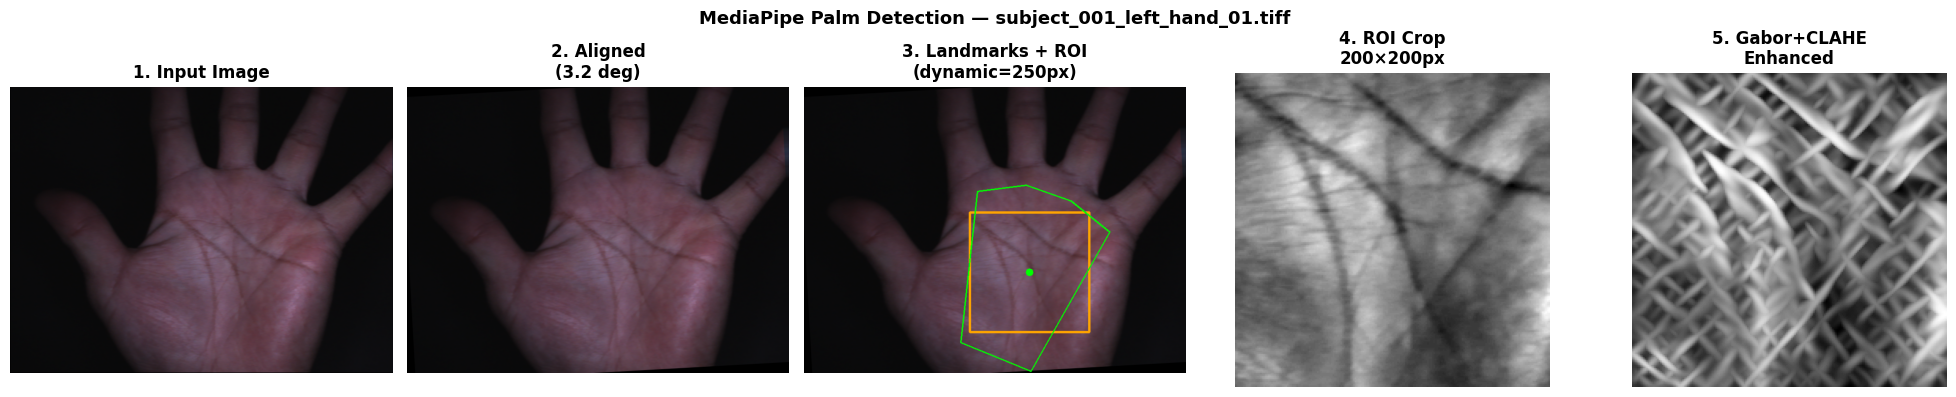

  Centroid      : (472, 389)
  ROI rect      : (347, 264, 597, 514)
  Angle         : 3.21 deg
  Dynamic size  : 250px
  Fallback      : False
  Palm area     : 79446 px²


In [12]:
# ─────────────────────────────────────────────────────────────────────
# OPENVC PALM DETECTOR
# Pipeline:
#   1. YCrCb skin color segmentation
#   2. HSV skin backup
#   3. Morphological cleaning (open → close → dilate)
#   4. Cari kontur terbesar → centroid
#   5. Center ROI crop 200×200
# ─────────────────────────────────────────────────────────────────────

# ── Visualisasi pada 1 sample ──
exts    = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
samples = [f for f in os.listdir(Config.DATASET_PATH) if f.lower().endswith(exts)]

if not samples:
    print('⚠️  Folder dataset kosong!')
else:
    img_sample = cv2.imread(os.path.join(Config.DATASET_PATH, samples[0]))
    roi_sample, dbg_sample = detect_palm_opencv(img_sample, debug=True)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'MediaPipe Palm Detection — {samples[0]}', fontsize=13, fontweight='bold')

    # 1. Original
    axes[0].imshow(cv2.cvtColor(img_sample, cv2.COLOR_BGR2RGB))
    axes[0].set_title('1. Input Image', fontweight='bold'); axes[0].axis('off')

    # 2. Aligned
    axes[1].imshow(cv2.cvtColor(dbg_sample['img_aligned'], cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'2. Aligned\n({dbg_sample["angle"]:.1f} deg)', fontweight='bold')
    axes[1].axis('off')

    # 3. Landmarks + ROI box
    img_ann = dbg_sample['img_aligned'].copy()
    rx, ry, rx2, ry2 = dbg_sample['roi_rect']
    cx_, cy_ = dbg_sample['cx'], dbg_sample['cy']
    cv2.rectangle(img_ann, (rx, ry), (rx2, ry2), (0, 165, 255), 3)
    cv2.circle(img_ann, (cx_, cy_), 8, (0, 255, 0), -1)
    if dbg_sample['contour'] is not None:
        cv2.drawContours(img_ann, [dbg_sample['contour']], -1, (0, 255, 0), 2)
    axes[2].imshow(cv2.cvtColor(img_ann, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f'3. Landmarks + ROI\n(dynamic={dbg_sample["dynamic_roi_size"]}px)', fontweight='bold')
    axes[2].axis('off')

    # 4. ROI crop
    axes[3].imshow(roi_sample, cmap='gray')
    axes[3].set_title(f'4. ROI Crop\n{Config.ROI_SIZE}×{Config.ROI_SIZE}px', fontweight='bold')
    axes[3].axis('off')

    # 5. Enhanced
    enhanced_preview = enhance_gabor(roi_sample)
    axes[4].imshow(enhanced_preview, cmap='gray')
    axes[4].set_title('5. Gabor+CLAHE\nEnhanced', fontweight='bold')
    axes[4].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_PATH, '01_palm_detection.png'), dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  Centroid      : ({cx_}, {cy_})')
    print(f'  ROI rect      : {dbg_sample["roi_rect"]}')
    print(f'  Angle         : {dbg_sample["angle"]:.2f} deg')
    print(f'  Dynamic size  : {dbg_sample["dynamic_roi_size"]}px')
    print(f'  Fallback      : {dbg_sample["fallback"]}')
    print(f'  Palm area     : {dbg_sample["area"]:.0f} px²')


## Cell 4 — HOG-SGF Extraction (Visualisasi)

In [13]:
def extract_hog_sgf(img_gray, hog_orient=None, hog_pixels=None, hog_cells=None, visualize=False):
    """
    HOG-SGF sesuai paper.
    HOG: 1764 dim (default)
    SGF: 48 dim (24 sudut × mean+std)
    Total: 1812 dim + L2-norm
    """
    orient = hog_orient or Config.HOG_ORIENT
    pixels = hog_pixels or Config.HOG_PIXELS
    cells  = hog_cells  or Config.HOG_CELLS

    img_64 = cv2.resize(img_gray, (Config.IMAGE_SIZE, Config.IMAGE_SIZE))

    # ── HOG ──
    if visualize:
        hog_feat, hog_img = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels), cells_per_block=(cells, cells),
            block_norm='L2', visualize=True
        )
    else:
        hog_feat = hog(
            img_64, orientations=orient,
            pixels_per_cell=(pixels, pixels), cells_per_block=(cells, cells),
            block_norm='L2', visualize=False
        )
        hog_img = None

    # ── SGF ──
    img_f = img_64.astype(np.float32)
    Ix    = cv2.Sobel(img_f, cv2.CV_32F, 1, 0, ksize=3)
    Iy    = cv2.Sobel(img_f, cv2.CV_32F, 0, 1, ksize=3)

    sgf_feats = []
    for theta in Config.SGF_ANGLES:
        FR = np.cos(theta) * Ix + np.sin(theta) * Iy
        sgf_feats.append(np.mean(FR))
        sgf_feats.append(np.std(FR))

    sgf_feat = np.array(sgf_feats, dtype=np.float32)  # 48 dim

    # ── Gabung + L2 Normalize ──
    combined = np.concatenate([hog_feat, sgf_feat])
    norm     = np.linalg.norm(combined)
    if norm > 0:
        combined = combined / norm

    if visualize:
        return combined, hog_img, img_64, Ix, Iy
    return combined


## Cell 5 — Load Dataset

[5] Loading dataset dengan augmentasi...
  Total file     : 3000
  Augmentasi     : 3x per gambar
  Total efektif  : 12000 samples


Loading + Augmenting: 100%|██████████| 3000/3000 [05:11<00:00,  9.62it/s]



✓ Dataset loaded:
  Original   : 3000 samples
  Augmented  : 9000 samples
  Total      : 12000 samples | 300 subjects
  Feature dim: 264
  Train : 11100 (orig=2100, aug=9000)
  Test  : 900 (original only)


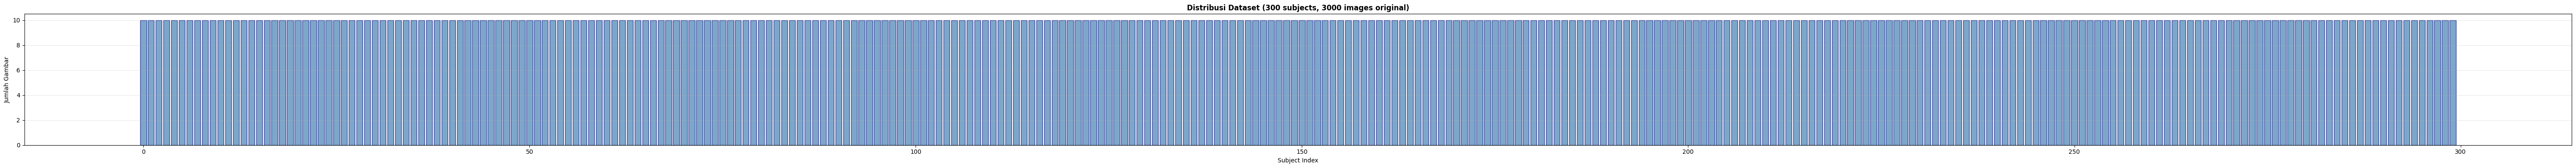

  Min per kelas: 10, Max: 10, Rata-rata: 10.0


In [14]:
def parse_label(fname):
    """Ekstrak subject ID dari nama file. Format: subject_282_left_hand_08.tiff"""
    name  = os.path.splitext(fname)[0]
    parts = name.split('_')
    for part in parts:
        if part.isdigit():
            return part
    return parts[0]


def load_dataset_with_augmentation(
    dataset_path, verbose=True,
    hog_orient=None, hog_pixels=None, hog_cells=None
):
    """
    Load dataset + augmentasi untuk training.
 
    Perubahan dari versi lama:
      - Setiap ROI di-augment N_AUG kali
      - Total dataset = original + augmented = 4x ukuran asli
      - Augmentasi hanya untuk TRAINING — test set tidak di-augment
      - Label augmented sama dengan original (same person)
 
    Args:
        dataset_path : path ke folder dataset
        verbose      : tampilkan progress
        hog_orient, hog_pixels, hog_cells : parameter HOG (opsional)
 
    Returns:
        X (np.ndarray): feature matrix
        y (np.ndarray): label array
        is_augmented (np.ndarray): boolean array, True = augmented sample
    """
    from tqdm import tqdm
    from skimage.feature import hog as skimage_hog
 
    # Import Config dari notebook (sudah ada)
    # Ini contoh — di notebook pakai Config.* langsung
 
    features     = []
    labels       = []
    is_augmented = []
 
    exts  = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
    files = [f for f in os.listdir(dataset_path) if f.lower().endswith(exts)]
 
    if verbose:
        print(f'  Total file     : {len(files)}')
        print(f'  Augmentasi     : {3}x per gambar')
        print(f'  Total efektif  : {len(files) * 4} samples')
 
    for fname in tqdm(files, desc='Loading + Augmenting', disable=not verbose):
        img = cv2.imread(os.path.join(dataset_path, fname))
        if img is None:
            continue
 
        label    = parse_label(fname)
        roi, _   = detect_palm_opencv(img)
        enhanced = enhance_gabor(roi)  # use_dog=False by default
 
        # ── Original ──
        feat = extract_hog_sgf(enhanced,
                               hog_orient=hog_orient,
                               hog_pixels=hog_pixels,
                               hog_cells=hog_cells)
        features.append(feat)
        labels.append(label)
        is_augmented.append(False)
 
        # ── Augmented ──
        aug_rois = augment_roi(roi)
        for aug_roi in aug_rois:
            aug_enhanced = enhance_gabor(aug_roi)  # use_dog=False
            aug_feat     = extract_hog_sgf(aug_enhanced,
                                           hog_orient=hog_orient,
                                           hog_pixels=hog_pixels,
                                           hog_cells=hog_cells)
            features.append(aug_feat)
            labels.append(label)
            is_augmented.append(True)
 
    X            = np.array(features)
    y            = np.array(labels)
    is_augmented = np.array(is_augmented)
 
    if verbose:
        orig_count = (~is_augmented).sum()
        aug_count  = is_augmented.sum()
        print(f'\n✓ Dataset loaded:')
        print(f'  Original   : {orig_count} samples')
        print(f'  Augmented  : {aug_count} samples')
        print(f'  Total      : {len(X)} samples | {len(np.unique(y))} subjects')
        print(f'  Feature dim: {X.shape[1]}')
 
    return X, y, is_augmented

print('[5] Loading dataset dengan augmentasi...')

# Load dataset + augmentasi
X, y, is_aug = load_dataset_with_augmentation(Config.DATASET_PATH)

# Split HANYA dari data original (bukan augmented)
# agar test set bersih dan tidak overlap dengan training
X_orig = X[~is_aug]
y_orig = y[~is_aug]

X_train_orig, X_test, y_train_orig, y_test = train_test_split(
    X_orig, y_orig,
    test_size=0.3, stratify=y_orig, random_state=42
)

# Tambahkan augmented ke training — hanya subject yang ada di train
train_subjects = set(y_train_orig)
mask_aug       = np.array([label in train_subjects for label in y[is_aug]])
X_aug_train    = X[is_aug][mask_aug]
y_aug_train    = y[is_aug][mask_aug]

X_train = np.vstack([X_train_orig, X_aug_train])
y_train = np.concatenate([y_train_orig, y_aug_train])

print(f'  Train : {len(X_train)} (orig={len(X_train_orig)}, aug={mask_aug.sum()})')
print(f'  Test  : {len(X_test)} (original only)')

# Distribusi per kelas (dari data original)
unique_labels, counts = np.unique(y_orig, return_counts=True)
fig, ax = plt.subplots(figsize=(max(12, len(unique_labels)//5), 4))
ax.bar(range(len(unique_labels)), counts, color='steelblue', edgecolor='navy', alpha=0.7)
ax.set_title(f'Distribusi Dataset ({len(unique_labels)} subjects, {len(y_orig)} images original)', fontweight='bold')
ax.set_xlabel('Subject Index'); ax.set_ylabel('Jumlah Gambar')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_PATH, '04_dataset_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'  Min per kelas: {counts.min()}, Max: {counts.max()}, Rata-rata: {counts.mean():.1f}')


  StandardScaler normalization...

  PCA (variance=99%, whiten=True)...
  Komponen otomatis : 95 (dari 264 dim)
  Variance retained : 0.9908 (99.08%)
  Reduksi dimensi   : 264 → 95 (64.0%)


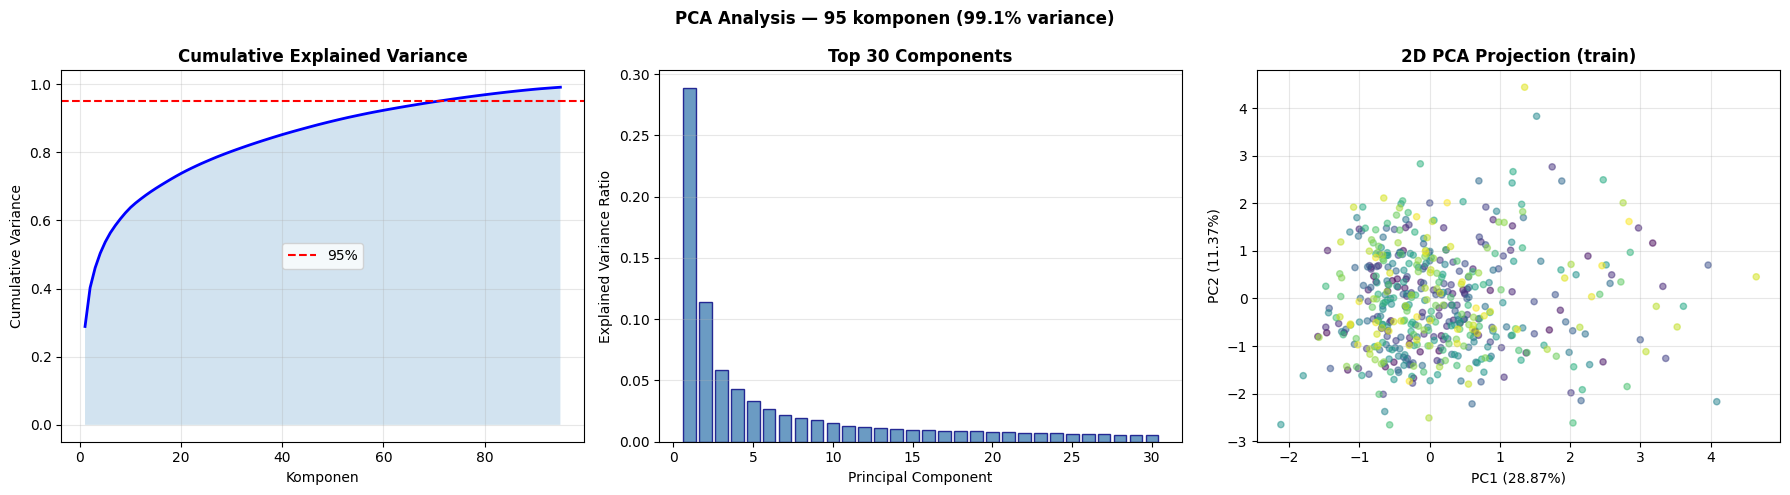

In [15]:


# ── StandardScaler ──
print('\n  StandardScaler normalization...')
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── PCA — variance otomatis 95% ──
print(f'\n  PCA (variance={Config.PCA_VARIANCE*100:.0f}%, whiten=True)...')
pca         = PCA(n_components=Config.PCA_VARIANCE, whiten=True, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

n_comp      = pca.n_components_
var_total   = np.sum(pca.explained_variance_ratio_)
print(f'  Komponen otomatis : {n_comp} (dari {X_train.shape[1]} dim)')
print(f'  Variance retained : {var_total:.4f} ({var_total*100:.2f}%)')
print(f'  Reduksi dimensi   : {X_train.shape[1]} → {n_comp} ({(1-n_comp/X_train.shape[1])*100:.1f}%)')

# ── Visualisasi PCA ──
cumsum = np.cumsum(pca.explained_variance_ratio_)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'PCA Analysis — {n_comp} komponen ({var_total*100:.1f}% variance)', fontweight='bold')

axes[0].plot(range(1, n_comp+1), cumsum, 'b-', lw=2)
axes[0].axhline(0.95, color='r', ls='--', label='95%')
axes[0].fill_between(range(1, n_comp+1), cumsum, alpha=0.2)
axes[0].set_xlabel('Komponen'); axes[0].set_ylabel('Cumulative Variance')
axes[0].set_title('Cumulative Explained Variance', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].bar(range(1, min(31, n_comp+1)), pca.explained_variance_ratio_[:30],
            color='steelblue', edgecolor='navy', alpha=0.8)
axes[1].set_xlabel('Principal Component'); axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('Top 30 Components', fontweight='bold'); axes[1].grid(True, alpha=0.3, axis='y')

n = min(500, len(X_train_pca))
sc_plot = axes[2].scatter(X_train_pca[:n, 0], X_train_pca[:n, 1],
                           c=range(n), cmap='viridis', s=20, alpha=0.5)
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[2].set_title('2D PCA Projection (train)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_PATH, '05_pca_analysis.png'), dpi=120, bbox_inches='tight')
plt.show()

## Cell 7 — Sweep Threshold Optimal (F1-Score Terbaik)

[7] Sweep threshold untuk menemukan F1-Score terbaik...
    (Threshold dipilih yang memberikan F1-Score tertinggi)


Sweeping threshold: 100%|██████████| 66/66 [00:05<00:00, 12.13it/s]



  ✓ Threshold optimal : 0.4500
    F1-Score (strict) : 0.9969
    Accuracy (strict) : 0.9956
    Rejection rate    : 0.3%


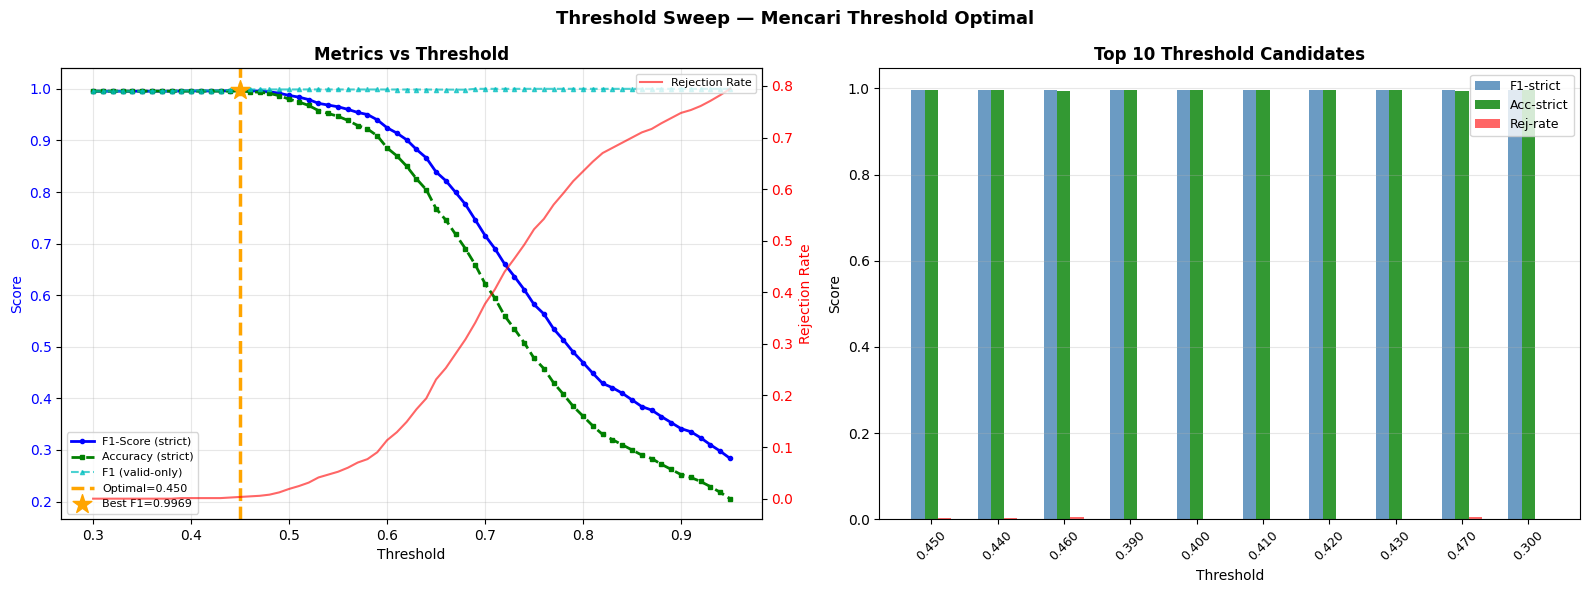

In [16]:
def cosine_predict(X_train_pca, y_train, X_test_pca, threshold):
    """Prediksi dengan cosine similarity + threshold."""
    sims   = cosine_similarity(X_test_pca, X_train_pca)
    preds, scores = [], []
    for s in sims:
        idx      = np.argmax(s)
        max_sim  = s[idx]
        preds.append(y_train[idx] if max_sim >= threshold else 'UNKNOWN')
        scores.append(max_sim)
    return np.array(preds), np.array(scores)


print('[7] Sweep threshold untuk menemukan F1-Score terbaik...')
print('    (Threshold dipilih yang memberikan F1-Score tertinggi)')

# Sweep threshold
thresholds_sweep = np.arange(0.30, 0.96, 0.01)  # sweep 0.30 – 0.95
results_sweep    = []

for th in tqdm(thresholds_sweep, desc='Sweeping threshold'):
    preds, scores_ = cosine_predict(X_train_pca, y_train, X_test_pca, th)
    valid = preds != 'UNKNOWN'

    # Strict accuracy: UNKNOWN dihitung salah
    preds_strict = np.where(valid, preds, '__WRONG__')
    acc_strict   = accuracy_score(y_test, preds_strict)

    # Valid-only metrics
    if valid.sum() > 0:
        y_tv, y_pv = y_test[valid], preds[valid]
        acc_v  = accuracy_score(y_tv, y_pv)
        f1_v   = f1_score(y_tv, y_pv, average='weighted', zero_division=0)
        prec_v = precision_score(y_tv, y_pv, average='weighted', zero_division=0)
        rec_v  = recall_score(y_tv, y_pv, average='weighted', zero_division=0)
    else:
        acc_v = f1_v = prec_v = rec_v = 0.0

    rej_rate = (~valid).mean()

    # F1 STRICT: hitung F1 dengan UNKNOWN sebagai class salah
    # → metric utama untuk memilih threshold
    results_sweep.append({
        'threshold' : th,
        'acc_strict': acc_strict,
        'acc_valid' : acc_v,
        'f1_valid'  : f1_v,
        'f1_strict' : f1_score(y_test, preds_strict, average='weighted', zero_division=0),
        'precision' : prec_v,
        'recall'    : rec_v,
        'rej_rate'  : rej_rate,
    })

# Pilih threshold dengan F1-strict terbaik
# (balance antara keamanan dan kemudahan)
best_idx  = np.argmax([r['f1_strict'] for r in results_sweep])
best      = results_sweep[best_idx]
THRESHOLD_OPTIMAL = best['threshold']

print(f'\n  ✓ Threshold optimal : {THRESHOLD_OPTIMAL:.4f}')
print(f'    F1-Score (strict) : {best["f1_strict"]:.4f}')
print(f'    Accuracy (strict) : {best["acc_strict"]:.4f}')
print(f'    Rejection rate    : {best["rej_rate"]*100:.1f}%')

# ── Visualisasi Sweep ──
ths   = [r['threshold']  for r in results_sweep]
f1s   = [r['f1_strict']  for r in results_sweep]
accs  = [r['acc_strict'] for r in results_sweep]
rejs  = [r['rej_rate']   for r in results_sweep]
f1v   = [r['f1_valid']   for r in results_sweep]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Threshold Sweep — Mencari Threshold Optimal', fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1b = ax1.twinx()
ax1.plot(ths, f1s,  'b-o',  ms=3, lw=2, label='F1-Score (strict)')
ax1.plot(ths, accs, 'g--s', ms=3, lw=2, label='Accuracy (strict)')
ax1.plot(ths, f1v,  'c--^', ms=3, lw=1.5, label='F1 (valid-only)', alpha=0.7)
ax1b.plot(ths, rejs, 'r-',  ms=3, lw=1.5, label='Rejection Rate', alpha=0.6)
ax1.axvline(THRESHOLD_OPTIMAL, color='orange', ls='--', lw=2.5,
            label=f'Optimal={THRESHOLD_OPTIMAL:.3f}')
ax1.scatter([THRESHOLD_OPTIMAL], [best['f1_strict']], color='orange', s=200, zorder=5,
            marker='*', label=f'Best F1={best["f1_strict"]:.4f}')
ax1.set_xlabel('Threshold'); ax1.set_ylabel('Score', color='b')
ax1b.set_ylabel('Rejection Rate', color='r')
ax1.set_title('Metrics vs Threshold', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='b')
ax1b.tick_params(axis='y', labelcolor='r')
ax1.legend(loc='lower left', fontsize=8)
ax1b.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Heatmap threshold perbandingan
top5_idx = sorted(range(len(f1s)), key=lambda i: f1s[i], reverse=True)[:10]
top5_th  = [ths[i] for i in top5_idx]
top5_f1  = [f1s[i] for i in top5_idx]
top5_acc = [accs[i] for i in top5_idx]
top5_rej = [rejs[i] for i in top5_idx]

x_pos = range(10)
axes[1].bar([x - 0.2 for x in x_pos], top5_f1,  0.2, label='F1-strict', color='steelblue', alpha=0.8)
axes[1].bar([x + 0.0 for x in x_pos], top5_acc, 0.2, label='Acc-strict', color='green', alpha=0.8)
axes[1].bar([x + 0.2 for x in x_pos], top5_rej, 0.2, label='Rej-rate', color='red', alpha=0.6)
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels([f'{t:.3f}' for t in top5_th], rotation=45, fontsize=9)
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Score')
axes[1].set_title('Top 10 Threshold Candidates', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_PATH, '06_threshold_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()

## Cell 8 — Hyperparameter Tuning (Default + [OPSIONAL] Uncomment Tuning)

In [17]:
# ─────────────────────────────────────────────────────────────────────
# PARAMETER DEFAULT 
# ─────────────────────────────────────────────────────────────────────
BEST_PARAMS = {
    'hog_orient'   : Config.HOG_ORIENT,
    'hog_pixels'   : Config.HOG_PIXELS,
    'hog_cells'    : Config.HOG_CELLS,
    'pca_variance' : Config.PCA_VARIANCE,
    'threshold'    : THRESHOLD_OPTIMAL,  
}
print('Parameter yang dipakai :')
for k, v in BEST_PARAMS.items():
    print(f'  {k:<15} : {v}')

Parameter yang dipakai :
  hog_orient      : 6
  hog_pixels      : 16
  hog_cells       : 2
  pca_variance    : 0.99
  threshold       : 0.4500000000000001


In [18]:
# # ─────────────────────────────────────────────────────────────────────
# # [OPSIONAL] HYPERPARAMETER TUNING — UNCOMMENT UNTUK MENJALANKAN
# # ─────────────────────────────────────────────────────────────────────

# PARAM_GRID = {
#     'hog_orient'   : [6, 9, 12],
#     'hog_pixels'   : [4, 8, 16],
#     'hog_cells'    : [2, 3],
#     'pca_variance' : [0.90, 0.95, 0.99],
# }

# def run_one_config(orient, pixels, cells, pca_var, X_tr, y_tr, X_ts, y_ts):
#     """Jalankan satu kombinasi, return F1-strict terbaik."""
#     # Re-ekstrak fitur dengan parameter HOG baru
#     exts  = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
#     files = [f for f in os.listdir(Config.DATASET_PATH) if f.lower().endswith(exts)]
#     feats, labs = [], []
#     for fname in files:
#         img = cv2.imread(os.path.join(Config.DATASET_PATH, fname))
#         if img is None: continue
#         roi, _   = detect_palm_opencv(img)
#         enhanced = enhance_gabor(roi)
#         feat     = extract_hog_sgf(enhanced, hog_orient=orient,
#                                    hog_pixels=pixels, hog_cells=cells)
#         feats.append(feat); labs.append(parse_label(fname))
#     X_, y_ = np.array(feats), np.array(labs)
#     X_tr_, X_ts_, y_tr_, y_ts_ = train_test_split(X_, y_, test_size=0.3,
#                                                    stratify=y_, random_state=42)
#     scl = StandardScaler()
#     X_tr_sc = scl.fit_transform(X_tr_)
#     X_ts_sc = scl.transform(X_ts_)
#     pca_    = PCA(n_components=pca_var, whiten=True, random_state=42)
#     X_tr_p  = pca_.fit_transform(X_tr_sc)
#     X_ts_p  = pca_.transform(X_ts_sc)
#     # Sweep threshold
#     best_f1, best_th = 0, 0.5
#     for th in np.arange(0.30, 0.96, 0.05):
#         preds, _ = cosine_predict(X_tr_p, y_tr_, X_ts_p, th)
#         valid    = preds != 'UNKNOWN'
#         ps       = np.where(valid, preds, '__WRONG__')
#         f1_      = f1_score(y_ts_, ps, average='weighted', zero_division=0)
#         if f1_ > best_f1:
#             best_f1, best_th = f1_, th
#     return {
#         'orient': orient, 'pixels': pixels, 'cells': cells,
#         'pca_var': pca_var, 'best_threshold': best_th,
#         'best_f1': best_f1, 'n_comp': pca_.n_components_
#     }

# from itertools import product as iterproduct
# combos     = list(iterproduct(PARAM_GRID['hog_orient'],
#                               PARAM_GRID['hog_pixels'],
#                               PARAM_GRID['hog_cells'],
#                               PARAM_GRID['pca_variance']))
# print(f'Total kombinasi: {len(combos)}')

# tuning_results = []
# for i, (orient, pixels, cells, pca_var) in enumerate(tqdm(combos, desc='Tuning')):
#     r = run_one_config(orient, pixels, cells, pca_var, X_train, y_train, X_test, y_test)
#     tuning_results.append(r)
#     if (i+1) % 5 == 0:
#         print(f'  [{i+1}/{len(combos)}] best so far: F1={max(x["best_f1"] for x in tuning_results):.4f}')

# best_tune   = max(tuning_results, key=lambda r: r['best_f1'])
# BEST_PARAMS = {
#     'hog_orient'   : best_tune['orient'],
#     'hog_pixels'   : best_tune['pixels'],
#     'hog_cells'    : best_tune['cells'],
#     'pca_variance' : best_tune['pca_var'],
#     'threshold'    : best_tune['best_threshold'],
# }
# print('\n✓ BEST PARAMS dari tuning:')
# for k, v in BEST_PARAMS.items():
#     print(f'  {k:<15} : {v}')
# print(f'  F1-Score terbaik: {best_tune["best_f1"]:.4f}')
# print(f'  PCA n_components: {best_tune["n_comp"]}')

# # Visualisasi tuning results
# fig, ax = plt.subplots(figsize=(14, 5))
# f1_vals = [r['best_f1'] for r in tuning_results]
# labels_ = [f"or={r['orient']},px={r['pixels']},bl={r['cells']},pca={r['pca_var']}" for r in tuning_results]
# sorted_idx = np.argsort(f1_vals)[::-1][:20]
# ax.barh(range(20), [f1_vals[i] for i in sorted_idx],
#         color='steelblue', alpha=0.8, edgecolor='navy')
# ax.set_yticks(range(20))
# ax.set_yticklabels([labels_[i] for i in sorted_idx], fontsize=8)
# ax.set_xlabel('F1-Score (strict)'); ax.set_title('Top 20 Hyperparameter Combinations', fontweight='bold')
# ax.grid(True, alpha=0.3, axis='x')
# plt.tight_layout()
# plt.savefig(os.path.join(Config.OUTPUT_PATH, '07_tuning_results.png'), dpi=120, bbox_inches='tight')
# plt.show()

# print('Cell 8 selesai — pakai BEST_PARAMS default.')
# print('Uncomment blok di atas untuk tuning otomatis.')

## Cell 9 — Evaluasi dengan Parameter Terbaik

[9] Evaluasi dengan BEST_PARAMS...

  HASIL EVALUASI
  Threshold (optimal)  : 0.4500
  PCA n_components     : 95
  Variance retained    : 0.9908

  Total test           : 3600
  Accepted             : 2915 (81.0%)
  Rejected (UNKNOWN)   : 685 (19.0%)

  [STRICT]  Accuracy   : 0.7933 (79.33%)

  [VALID]   Accuracy   : 0.9798 (97.98%)
  [VALID]   Precision  : 0.9816
  [VALID]   Recall     : 0.9798
  [VALID]   F1-Score   : 0.9796


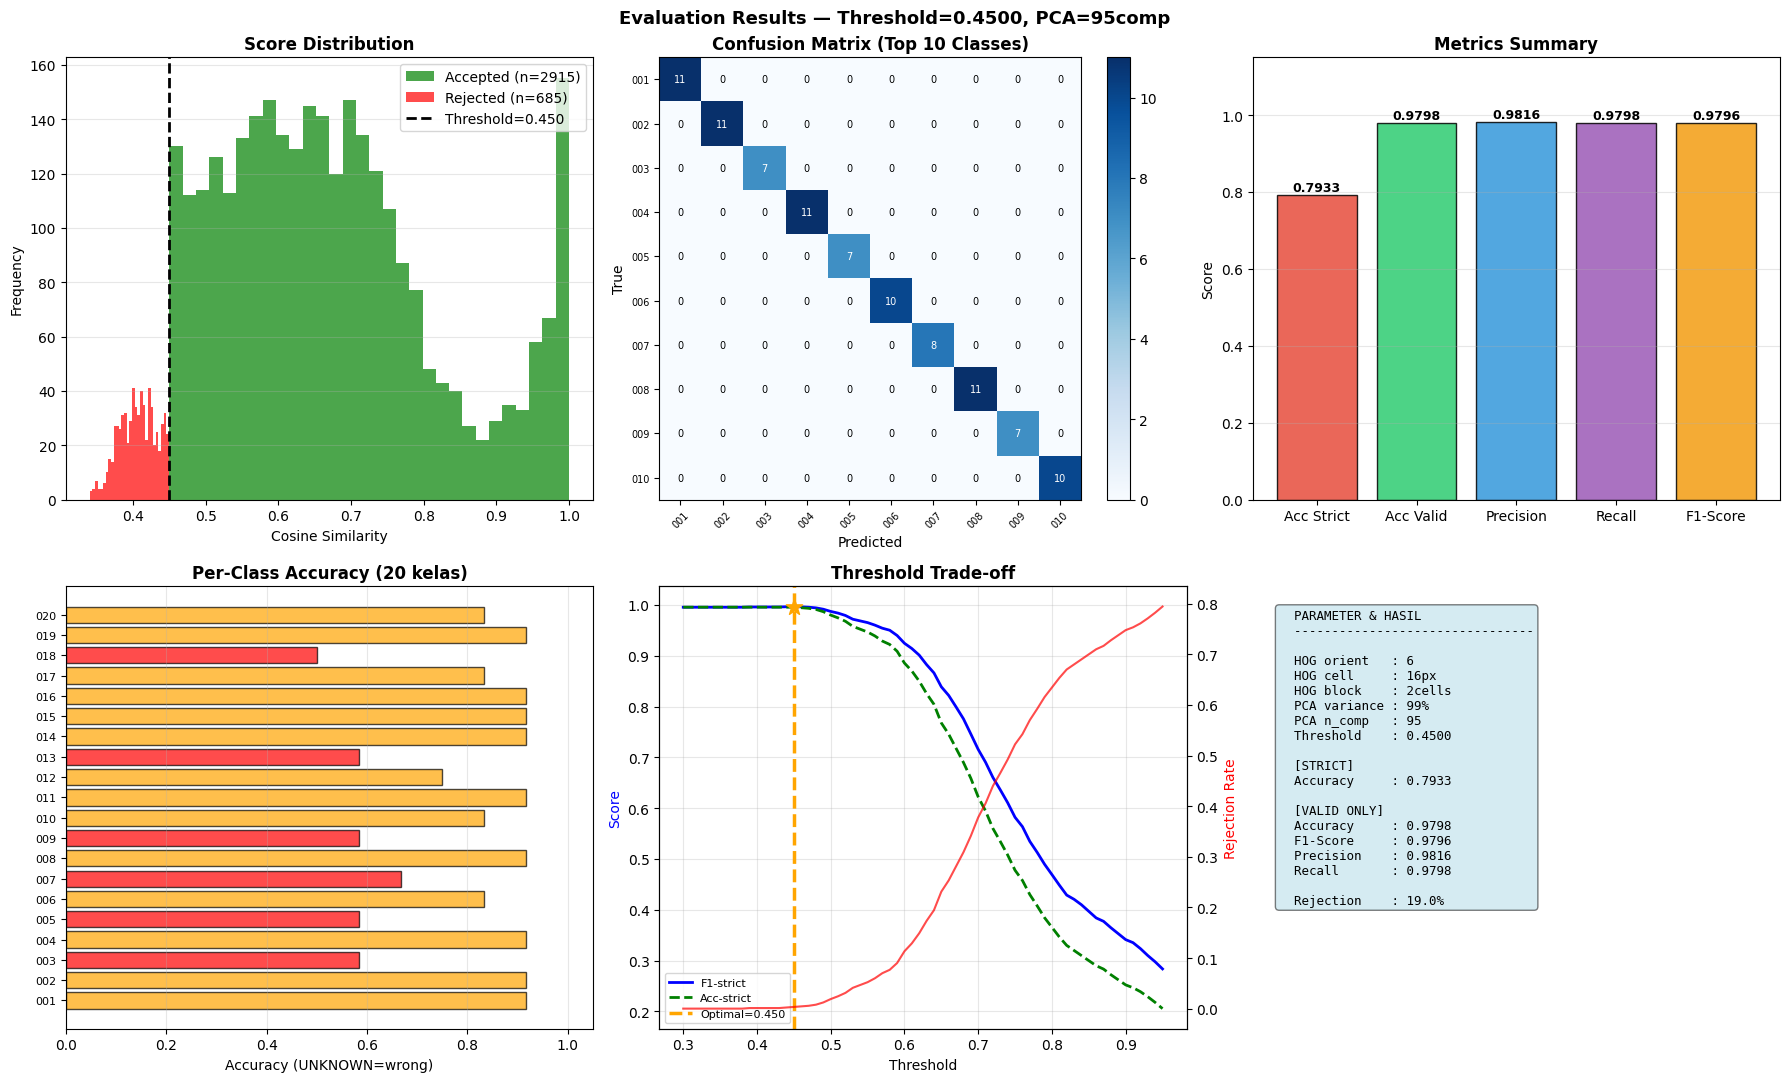

In [19]:
print('[9] Evaluasi dengan BEST_PARAMS...')

# Split dari X_orig, y_orig (data ORIGINAL saja, tanpa augmented).
# PENTING: jangan split dari X, y (yang sudah berisi augmented) —
# augmented sample dari orang yang sama akan masuk test set dan
# menyebabkan data leakage → metrik terlalu optimis.
# Augmented hanya boleh masuk training, test set harus bersih.
X_tr_orig, X_ts, y_tr_orig, y_ts = train_test_split(
    X_orig, y_orig, test_size=0.3, stratify=y_orig, random_state=42
)

# Tambahkan augmented ke training (hanya subject yang ada di train)
_train_subjects = set(y_tr_orig)
_mask_aug       = np.array([lbl in _train_subjects for lbl in y[is_aug]])
X_tr = np.vstack([X_tr_orig, X[is_aug][_mask_aug]])
y_tr = np.concatenate([y_tr_orig, y[is_aug][_mask_aug]])

scaler_best = StandardScaler()
X_tr_sc     = scaler_best.fit_transform(X_tr)
X_ts_sc     = scaler_best.transform(X_ts)

pca_best    = PCA(n_components=BEST_PARAMS['pca_variance'], whiten=True, random_state=42)
X_tr_pca    = pca_best.fit_transform(X_tr_sc)
X_ts_pca    = pca_best.transform(X_ts_sc)

best_thr    = BEST_PARAMS['threshold']
y_pred, scores = cosine_predict(X_tr_pca, y_tr, X_ts_pca, best_thr)

# ── Metrics ──
valid         = y_pred != 'UNKNOWN'
y_pred_strict = np.where(valid, y_pred, '__WRONG__')
acc_strict    = accuracy_score(y_ts, y_pred_strict)

if valid.sum() > 0:
    y_tv, y_pv = y_ts[valid], y_pred[valid]
    acc_v  = accuracy_score(y_tv, y_pv)
    prec_v = precision_score(y_tv, y_pv, average='weighted', zero_division=0)
    rec_v  = recall_score(y_tv, y_pv, average='weighted', zero_division=0)
    f1_v   = f1_score(y_tv, y_pv, average='weighted', zero_division=0)
else:
    acc_v = prec_v = rec_v = f1_v = 0.0

rej_rate = (~valid).mean()

print('\n' + '='*60)
print('  HASIL EVALUASI')
print('='*60)
print(f'  Threshold (optimal)  : {best_thr:.4f}')
print(f'  PCA n_components     : {pca_best.n_components_}')
print(f'  Variance retained    : {np.sum(pca_best.explained_variance_ratio_):.4f}')
print()
print(f'  Total test           : {len(y_ts)}')
print(f'  Accepted             : {valid.sum()} ({valid.mean()*100:.1f}%)')
print(f'  Rejected (UNKNOWN)   : {(~valid).sum()} ({rej_rate*100:.1f}%)')
print()
print(f'  [STRICT]  Accuracy   : {acc_strict:.4f} ({acc_strict*100:.2f}%)')
print()
print(f'  [VALID]   Accuracy   : {acc_v:.4f} ({acc_v*100:.2f}%)')
print(f'  [VALID]   Precision  : {prec_v:.4f}')
print(f'  [VALID]   Recall     : {rec_v:.4f}')
print(f'  [VALID]   F1-Score   : {f1_v:.4f}')
print('='*60)

# Visualisasi hasil evaluasi
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f'Evaluation Results — Threshold={best_thr:.4f}, PCA={pca_best.n_components_}comp',
             fontsize=13, fontweight='bold')

# Score distribution
acc_s = scores[valid]
rej_s = scores[~valid]
ax = axes[0, 0]
if len(acc_s): ax.hist(acc_s, bins=30, alpha=0.7, color='green', label=f'Accepted (n={valid.sum()})')
if len(rej_s): ax.hist(rej_s, bins=30, alpha=0.7, color='red', label=f'Rejected (n={(~valid).sum()})')
ax.axvline(best_thr, color='black', ls='--', lw=2, label=f'Threshold={best_thr:.3f}')
ax.set_xlabel('Cosine Similarity'); ax.set_ylabel('Frequency')
ax.set_title('Score Distribution', fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3, axis='y')

# Confusion matrix (top 10 kelas)
unique_l = np.unique(y_ts)[:10]
ax = axes[0, 1]
if valid.sum() > 0:
    cm = confusion_matrix(y_ts[valid], y_pred[valid], labels=unique_l)
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(unique_l))); ax.set_yticks(range(len(unique_l)))
    ax.set_xticklabels(unique_l, fontsize=7, rotation=45)
    ax.set_yticklabels(unique_l, fontsize=7)
    plt.colorbar(im, ax=ax)
    for i in range(len(unique_l)):
        for j in range(len(unique_l)):
            ax.text(j, i, cm[i,j], ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=7)
ax.set_title('Confusion Matrix (Top 10 Classes)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')

# Metrics bar chart
ax = axes[0, 2]
metric_names = ['Acc Strict', 'Acc Valid', 'Precision', 'Recall', 'F1-Score']
metric_vals  = [acc_strict, acc_v, prec_v, rec_v, f1_v]
colors       = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12']
bars = ax.bar(metric_names, metric_vals, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.15); ax.set_title('Metrics Summary', fontweight='bold')
ax.set_ylabel('Score'); ax.grid(True, alpha=0.3, axis='y')

# Per-class accuracy (first 20)
unique20 = np.unique(y_ts)[:20]
ax = axes[1, 0]
per_class_acc = []
for lbl in unique20:
    mask_l = y_ts == lbl
    ps_l   = y_pred_strict[mask_l]
    yt_l   = y_ts[mask_l]
    per_class_acc.append(accuracy_score(yt_l, ps_l))
clrs_ = ['green' if a==1.0 else 'orange' if a>=0.7 else 'red' for a in per_class_acc]
ax.barh(range(len(unique20)), per_class_acc, color=clrs_, edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(unique20))); ax.set_yticklabels(unique20, fontsize=8)
ax.set_xlim(0, 1.05); ax.set_xlabel('Accuracy (UNKNOWN=wrong)')
ax.set_title('Per-Class Accuracy (20 kelas)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Threshold trade-off (kembali sweep)
ax = axes[1, 1]
ax2b = ax.twinx()
ax.plot(ths, f1s,  'b-',  lw=2, label='F1-strict')
ax.plot(ths, accs, 'g--', lw=2, label='Acc-strict')
ax2b.plot(ths, rejs, 'r-', lw=1.5, label='Reject Rate', alpha=0.7)
ax.axvline(best_thr, color='orange', ls='--', lw=2.5, label=f'Optimal={best_thr:.3f}')
ax.scatter([best_thr], [best['f1_strict']], color='orange', s=150, zorder=5, marker='*')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score', color='b')
ax2b.set_ylabel('Rejection Rate', color='r')
ax.set_title('Threshold Trade-off', fontweight='bold')
ax.legend(loc='lower left', fontsize=8); ax.grid(True, alpha=0.3)

# Info box
ax = axes[1, 2]; ax.axis('off')
ax.text(0.05, 0.95,
    f'  PARAMETER & HASIL\n  {"-"*32}\n\n'
    f'  HOG orient   : {BEST_PARAMS["hog_orient"]}\n'
    f'  HOG cell     : {BEST_PARAMS["hog_pixels"]}px\n'
    f'  HOG block    : {BEST_PARAMS["hog_cells"]}cells\n'
    f'  PCA variance : {BEST_PARAMS["pca_variance"]*100:.0f}%\n'
    f'  PCA n_comp   : {pca_best.n_components_}\n'
    f'  Threshold    : {best_thr:.4f}\n\n'
    f'  [STRICT]\n'
    f'  Accuracy     : {acc_strict:.4f}\n\n'
    f'  [VALID ONLY]\n'
    f'  Accuracy     : {acc_v:.4f}\n'
    f'  F1-Score     : {f1_v:.4f}\n'
    f'  Precision    : {prec_v:.4f}\n'
    f'  Recall       : {rec_v:.4f}\n\n'
    f'  Rejection    : {rej_rate*100:.1f}%',
    transform=ax.transAxes, fontsize=9, va='top', fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5)
)

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_PATH, '08_evaluation_results.png'), dpi=120, bbox_inches='tight')
plt.show()

## Cell 10 — Export Model Terbaik

In [20]:
print('[10] Menyimpan model terbaik...')

# Simpan scaler, pca, threshold
joblib.dump(scaler_best,  os.path.join(Config.MODELS_DIR, 'scaler.pkl'))
joblib.dump(pca_best,     os.path.join(Config.MODELS_DIR, 'pca.pkl'))
joblib.dump(best_thr,     os.path.join(Config.MODELS_DIR, 'threshold.pkl'))

# Simpan X_train_pca dan y_train untuk matching di API
# (cosine similarity butuh reference database)
# Catatan: X_tr_pca berasal dari split bersih (original only + augmented train)
# — test set sudah dipisah dan tidak ikut tersimpan di sini
joblib.dump(X_tr_pca, os.path.join(Config.MODELS_DIR, 'X_train_pca.pkl'))
joblib.dump(y_tr,     os.path.join(Config.MODELS_DIR, 'y_train.pkl'))

# Simpan config terbaik
import json
best_config = {
    'hog_orient'    : int(BEST_PARAMS['hog_orient']),
    'hog_pixels'    : int(BEST_PARAMS['hog_pixels']),
    'hog_cells'     : int(BEST_PARAMS['hog_cells']),
    'pca_variance'  : float(BEST_PARAMS['pca_variance']),
    'pca_n_comp'    : int(pca_best.n_components_),
    'threshold'     : float(best_thr),
    'acc_strict'    : float(acc_strict),
    'acc_valid'     : float(acc_v),
    'f1_valid'      : float(f1_v),
    'precision'     : float(prec_v),
    'recall'        : float(rec_v),
    'rejection_rate': float(rej_rate),
    'n_train'       : int(len(X_tr)),
    'n_test'        : int(len(X_ts)),
    'n_subjects'    : int(len(np.unique(y))),
    'feature_dim'   : int(X.shape[1]),
}
with open(os.path.join(Config.MODELS_DIR, 'best_config.json'), 'w') as f:
    json.dump(best_config, f, indent=2)

print(f'  ✓ scaler.pkl      → {Config.MODELS_DIR}/')
print(f'  ✓ pca.pkl         → {Config.MODELS_DIR}/')
print(f'  ✓ threshold.pkl   → {Config.MODELS_DIR}/  (value: {best_thr:.4f})')
print(f'  ✓ X_train_pca.pkl → {Config.MODELS_DIR}/')
print(f'  ✓ y_train.pkl     → {Config.MODELS_DIR}/')
print(f'  ✓ best_config.json→ {Config.MODELS_DIR}/')
print()
print('  CONFIG TERBAIK:')
for k, v in best_config.items():
    print(f'    {k:<20}: {v}')

[10] Menyimpan model terbaik...
  ✓ scaler.pkl      → models/
  ✓ pca.pkl         → models/
  ✓ threshold.pkl   → models/  (value: 0.4500)
  ✓ X_train_pca.pkl → models/
  ✓ y_train.pkl     → models/
  ✓ best_config.json→ models/

  CONFIG TERBAIK:
    hog_orient          : 6
    hog_pixels          : 16
    hog_cells           : 2
    pca_variance        : 0.99
    pca_n_comp          : 95
    threshold           : 0.4500000000000001
    acc_strict          : 0.7933333333333333
    acc_valid           : 0.9797598627787307
    f1_valid            : 0.9796255297021282
    precision           : 0.981622240918982
    recall              : 0.9797598627787307
    rejection_rate      : 0.19027777777777777
    n_train             : 8400
    n_test              : 3600
    n_subjects          : 300
    feature_dim         : 264


## Cell 11 — Visualisasi Pipeline Lengkap

[11] Visualisasi pipeline lengkap...


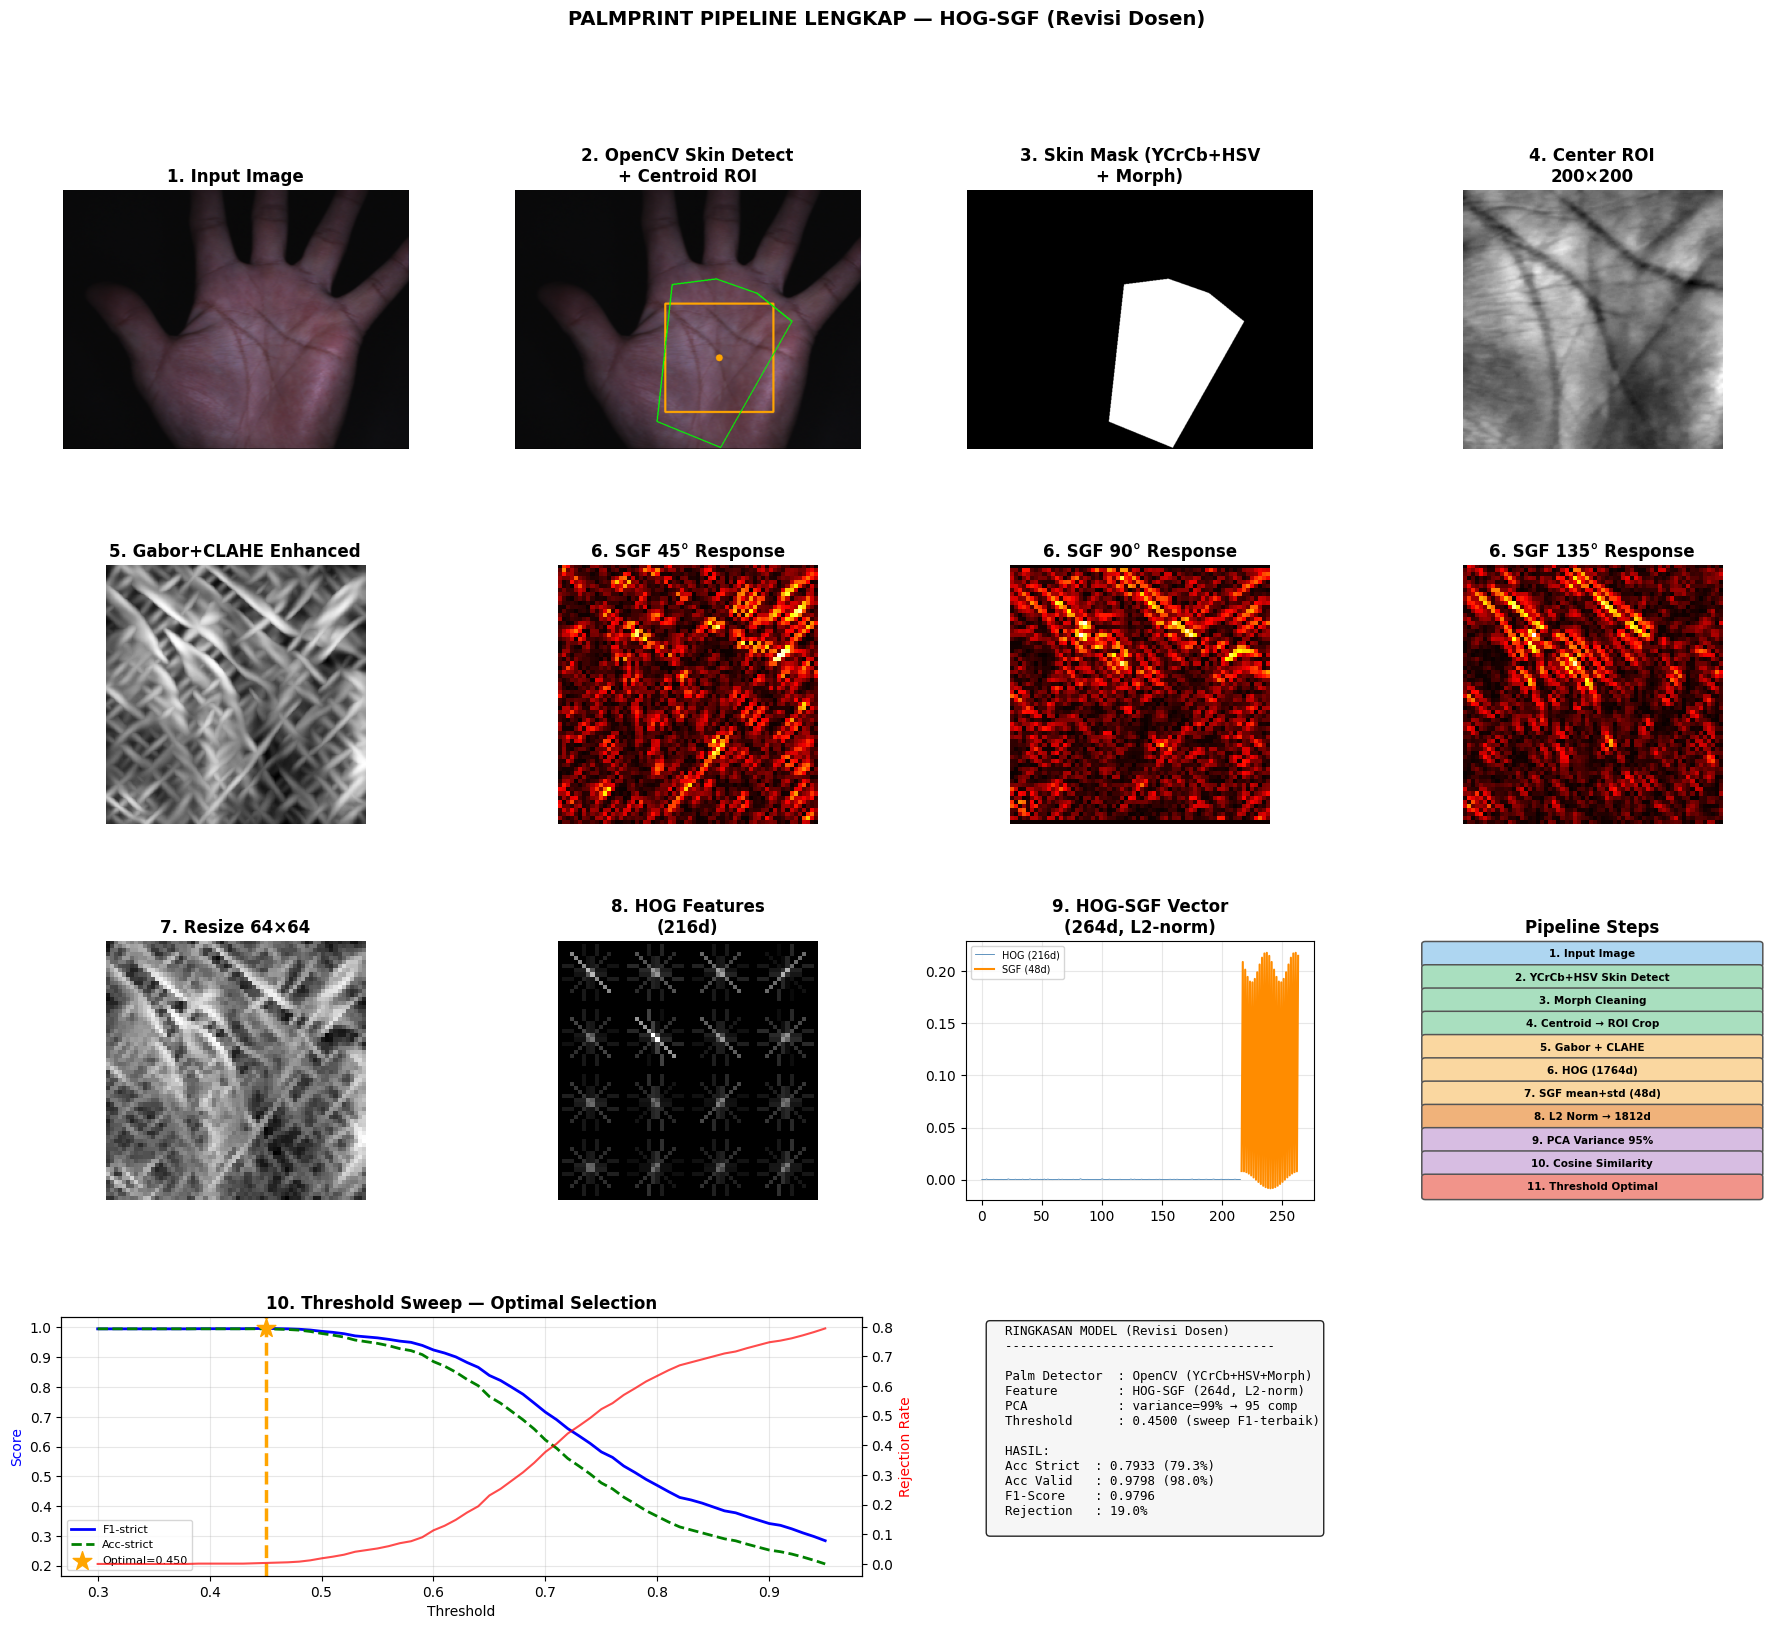


✅ SELESAI! Semua file tersimpan di:
   Model  : d:\xampp\htdocs\palmprint-backend\palmprint-ml\models/
   Output : d:\xampp\htdocs\palmprint-backend\palmprint-ml\results/

Files model:
  best_config.json          (0.4 KB)
  pca.pkl                   (201.2 KB)
  scaler.pkl                (6.8 KB)
  threshold.pkl             (0.1 KB)
  X_train_pca.pkl           (6234.6 KB)
  y_train.pkl               (98.7 KB)


In [21]:
print('[11] Visualisasi pipeline lengkap...')

if samples:
    img_vis  = cv2.imread(os.path.join(Config.DATASET_PATH, samples[0]))
    roi_vis, dbg_vis = detect_palm_opencv(img_vis)
    enh_vis  = enhance_gabor(roi_vis)
    feat_vis, hog_img_vis, img64_vis, Ix_vis, Iy_vis = extract_hog_sgf(enh_vis, visualize=True)

    hog_dim_vis = len(feat_vis) - len(Config.SGF_ANGLES) * 2
    sgf_dim_vis = len(Config.SGF_ANGLES) * 2

    fig = plt.figure(figsize=(22, 18))
    gs  = GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.30)
    fig.suptitle('PALMPRINT PIPELINE LENGKAP — HOG-SGF (Revisi Dosen)', fontsize=14, fontweight='bold')

    # Row 0: Deteksi
    img_ann = img_vis.copy()
    cx__, cy__ = dbg_vis['cx'], dbg_vis['cy']
    rx_, ry_, rx2_, ry2_ = dbg_vis['roi_rect']
    cv2.circle(img_ann, (cx__, cy__), 8, (0, 165, 255), -1)
    cv2.rectangle(img_ann, (rx_, ry_), (rx2_, ry2_), (0, 165, 255), 3)
    if dbg_vis['contour'] is not None:
        cv2.drawContours(img_ann, [dbg_vis['contour']], -1, (0, 255, 0), 2)

    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
    ax.set_title('1. Input Image', fontweight='bold'); ax.axis('off')

    ax = fig.add_subplot(gs[0, 1])
    ax.imshow(cv2.cvtColor(img_ann, cv2.COLOR_BGR2RGB))
    ax.set_title('2. MediaPipe Aligned\n+ Centroid ROI', fontweight='bold'); ax.axis('off')

    ax = fig.add_subplot(gs[0, 2])
    ax.imshow(dbg_vis['mask_clean'], cmap='gray')
    ax.set_title('3. Landmarks + Hull\n(MediaPipe)', fontweight='bold'); ax.axis('off')

    ax = fig.add_subplot(gs[0, 3])
    ax.imshow(roi_vis, cmap='gray')
    ax.set_title(f'4. Center ROI\n{Config.ROI_SIZE}×{Config.ROI_SIZE}', fontweight='bold'); ax.axis('off')

    # Row 1: Enhancement & SGF
    ax = fig.add_subplot(gs[1, 0])
    ax.imshow(enh_vis, cmap='gray')
    ax.set_title('5. Gabor+CLAHE Enhanced', fontweight='bold'); ax.axis('off')

    sgf_vis_angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    sgf_vis_labels = ['SGF 0°', 'SGF 45°', 'SGF 90°', 'SGF 135°']
    for col, (theta, lbl) in enumerate(zip(sgf_vis_angles, sgf_vis_labels)):
        FR = np.cos(theta) * Ix_vis + np.sin(theta) * Iy_vis
        FR_n = cv2.normalize(np.abs(FR), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        if col == 0: continue  # sudah ditampilkan
        ax = fig.add_subplot(gs[1, col])
        ax.imshow(FR_n, cmap='hot')
        ax.set_title(f'6. {lbl} Response', fontweight='bold'); ax.axis('off')

    # Row 2: HOG & Feature Vector
    ax = fig.add_subplot(gs[2, 0])
    ax.imshow(img64_vis, cmap='gray')
    ax.set_title(f'7. Resize {Config.IMAGE_SIZE}×{Config.IMAGE_SIZE}', fontweight='bold'); ax.axis('off')

    ax = fig.add_subplot(gs[2, 1])
    ax.imshow(hog_img_vis, cmap='gray')
    ax.set_title(f'8. HOG Features\n({hog_dim_vis}d)', fontweight='bold'); ax.axis('off')

    ax = fig.add_subplot(gs[2, 2])
    ax.plot(feat_vis[:hog_dim_vis], lw=0.6, color='steelblue', label=f'HOG ({hog_dim_vis}d)')
    ax.plot(range(hog_dim_vis, hog_dim_vis+sgf_dim_vis),
            feat_vis[hog_dim_vis:], lw=1.5, color='darkorange', label=f'SGF ({sgf_dim_vis}d)')
    ax.set_title(f'9. HOG-SGF Vector\n({len(feat_vis)}d, L2-norm)', fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Pipeline steps box
    ax = fig.add_subplot(gs[2, 3]); ax.axis('off')
    steps_box = [
        ('1. Input Image',              '#AED6F1'),
        ('2. MediaPipe + Alignment',     '#A9DFBF'),
        ('3. Landmark + Dynamic ROI',   '#A9DFBF'),
        ('4. Centroid → ROI Crop',      '#A9DFBF'),
        ('5. Gabor + CLAHE',            '#FAD7A0'),
        ('6. HOG (1764d)',              '#FAD7A0'),
        ('7. SGF mean+std (48d)',       '#FAD7A0'),
        ('8. L2 Norm → 1812d',         '#F0B27A'),
        ('9. PCA Variance 95%',         '#D7BDE2'),
        ('10. Cosine Similarity',       '#D7BDE2'),
        ('11. Threshold Optimal',       '#F1948A'),
    ]
    n_s = len(steps_box); box_h = 0.078; gap = (1.0 - n_s*box_h)/(n_s+1)
    for i, (txt, color) in enumerate(steps_box):
        y_ = 1.0 - gap*(i+1) - box_h*(i+1)
        rect = patches.FancyBboxPatch((0.02, y_), 0.96, box_h,
                                       boxstyle='round,pad=0.01',
                                       facecolor=color, edgecolor='#555', lw=1.1,
                                       transform=ax.transAxes, clip_on=False)
        ax.add_patch(rect)
        ax.text(0.5, y_+box_h/2, txt, transform=ax.transAxes,
                fontsize=7.5, ha='center', va='center', fontweight='bold')
    ax.set_title('Pipeline Steps', fontweight='bold')

    # Row 3: Threshold & PCA summary
    ax = fig.add_subplot(gs[3, 0:2])
    ax2b_ = ax.twinx()
    ax.plot(ths, f1s,  'b-',  lw=2, label='F1-strict')
    ax.plot(ths, accs, 'g--', lw=2, label='Acc-strict')
    ax2b_.plot(ths, rejs, 'r-', lw=1.5, label='Reject Rate', alpha=0.7)
    ax.axvline(best_thr, color='orange', ls='--', lw=2.5)
    ax.scatter([best_thr], [best['f1_strict']], color='orange', s=200, zorder=5, marker='*',
               label=f'Optimal={best_thr:.3f}')
    ax.set_xlabel('Threshold'); ax.set_ylabel('Score', color='b')
    ax2b_.set_ylabel('Rejection Rate', color='r')
    ax.set_title('10. Threshold Sweep — Optimal Selection', fontweight='bold')
    ax.legend(loc='lower left', fontsize=8); ax.grid(True, alpha=0.3)

    ax = fig.add_subplot(gs[3, 2:4]); ax.axis('off')
    ax.text(0.03, 0.97,
        f'  RINGKASAN MODEL (Revisi Dosen)\n  {"-"*36}\n\n'
        f'  Palm Detector  : MediaPipe HandLandmarker (Fase 1A + Dynamic ROI)\n'
        f'  Feature        : HOG-SGF ({len(feat_vis)}d, L2-norm)\n'
        f'  PCA            : variance={Config.PCA_VARIANCE*100:.0f}% → {pca_best.n_components_} comp\n'
        f'  Threshold      : {best_thr:.4f} (sweep F1-terbaik)\n\n'
        f'  HASIL:\n'
        f'  Acc Strict  : {acc_strict:.4f} ({acc_strict*100:.1f}%)\n'
        f'  Acc Valid   : {acc_v:.4f} ({acc_v*100:.1f}%)\n'
        f'  F1-Score    : {f1_v:.4f}\n'
        f'  Rejection   : {rej_rate*100:.1f}%\n',
        transform=ax.transAxes, fontsize=9, va='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.85)
    )

    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_PATH, '09_pipeline_complete.png'), dpi=120, bbox_inches='tight')
    plt.show()

print('\n✅ SELESAI! Semua file tersimpan di:')
print(f'   Model  : {os.path.abspath(Config.MODELS_DIR)}/')
print(f'   Output : {os.path.abspath(Config.OUTPUT_PATH)}/')
print()
print('Files model:')
for f in os.listdir(Config.MODELS_DIR):
    path = os.path.join(Config.MODELS_DIR, f)
    size = os.path.getsize(path)
    print(f'  {f:<25} ({size/1024:.1f} KB)')

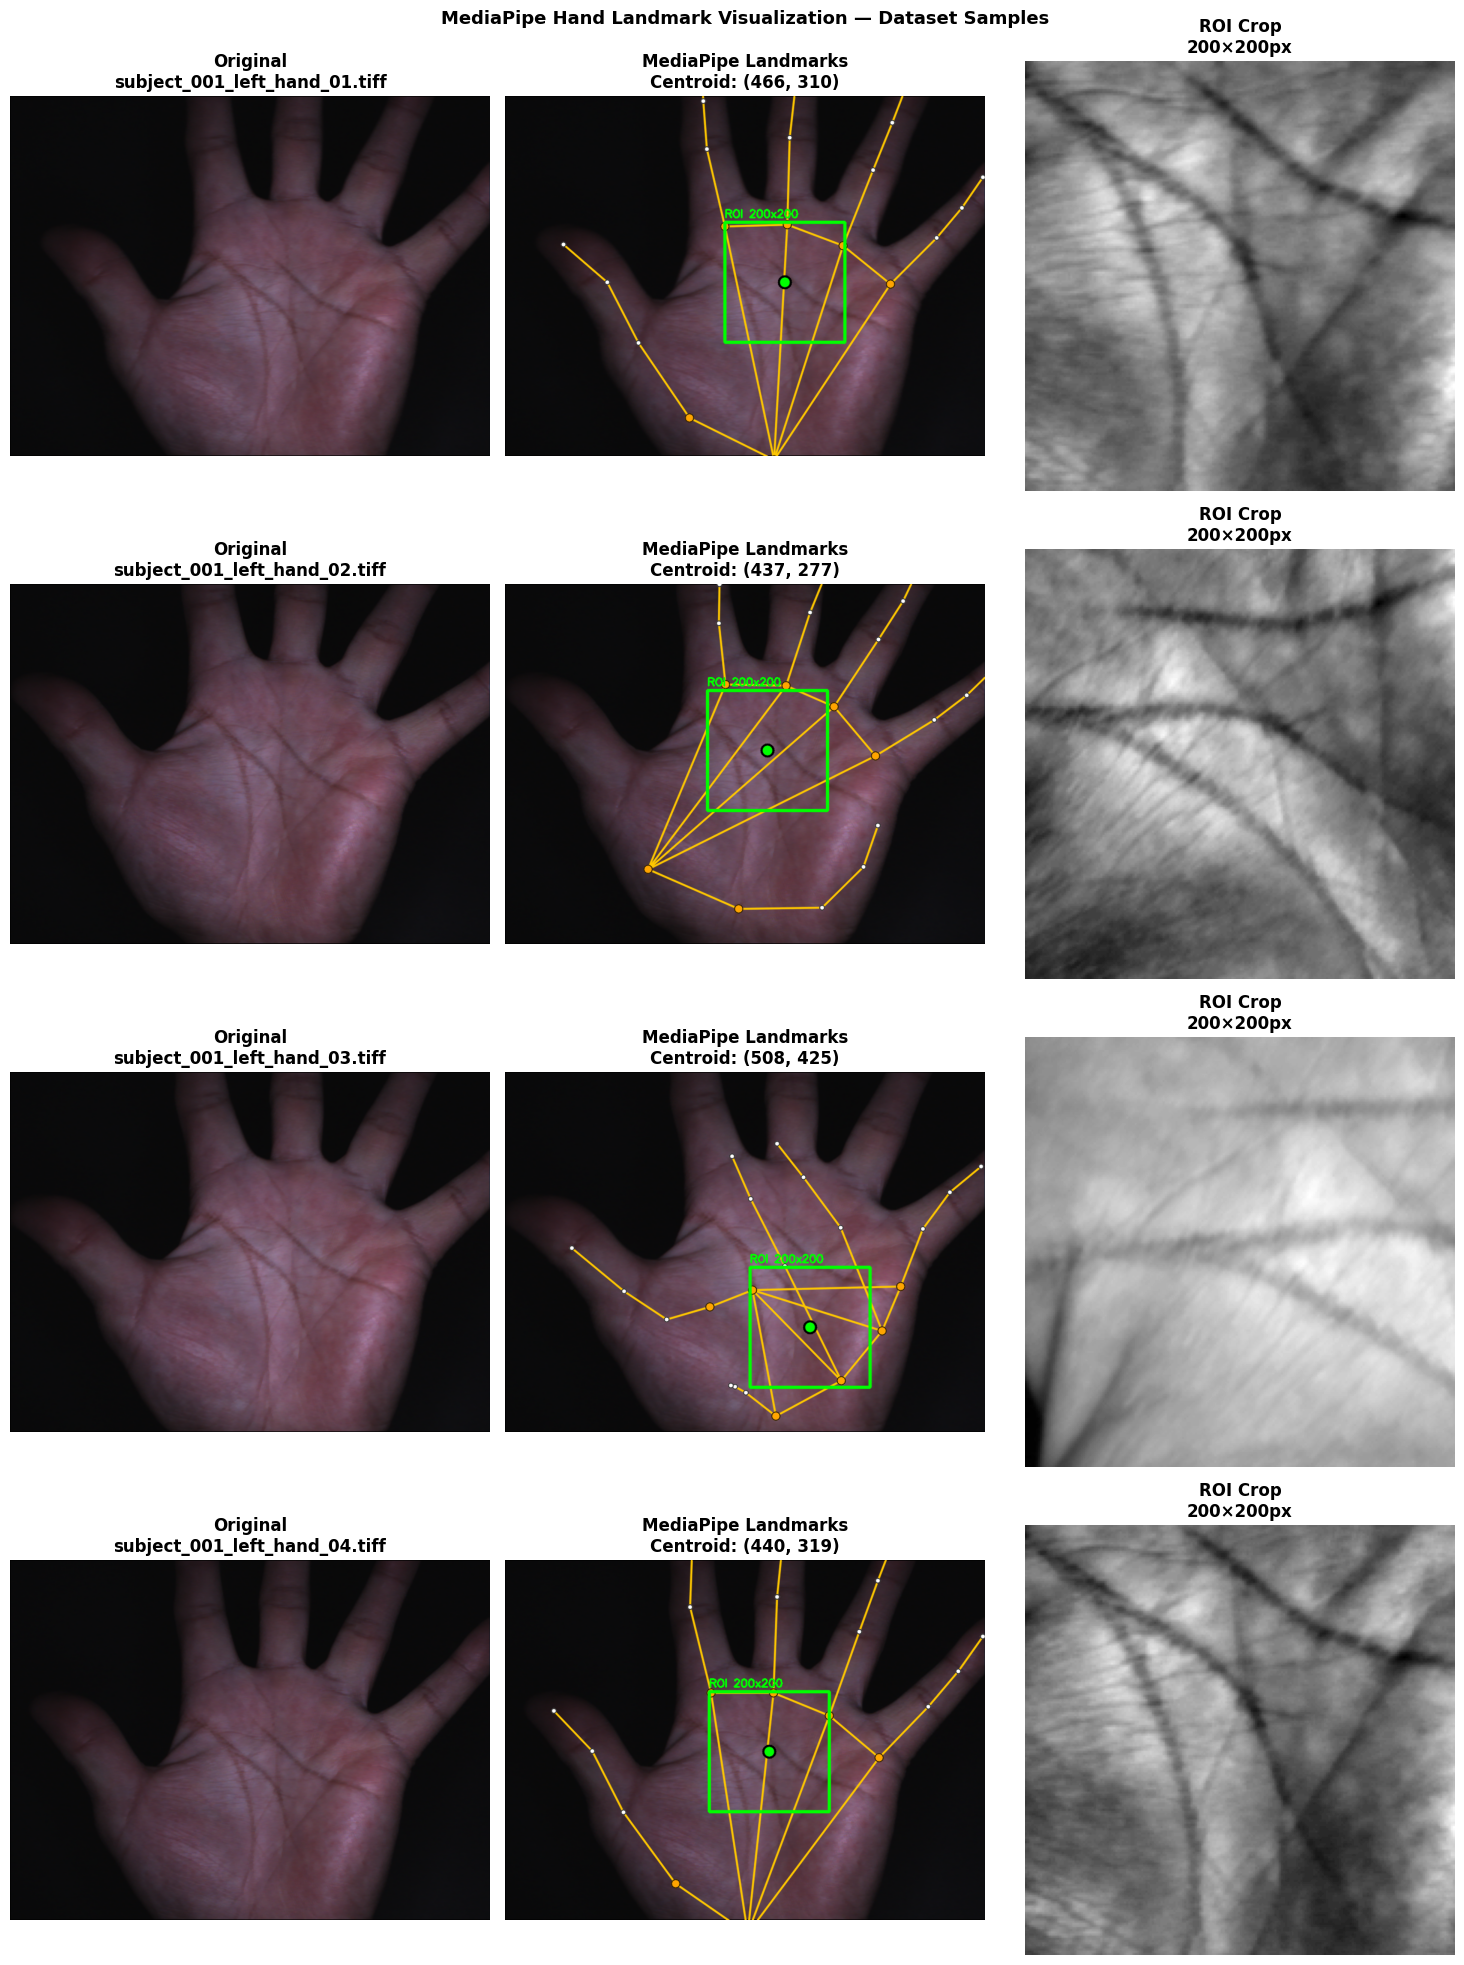

✓ Visualisasi MediaPipe landmark selesai


In [22]:
# ─────────────────────────────────────────────────────────────────────
# VISUALISASI MEDIAPIPE LANDMARK
# Tampilkan 21 landmark + koneksi + ROI box di atas gambar dataset
# ─────────────────────────────────────────────────────────────────────

import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from mediapipe.tasks.python.vision import HandLandmarker, HandLandmarkerOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode

# Koneksi antar landmark (sesuai MediaPipe hand topology)
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),         # ibu jari
    (0,5),(5,6),(6,7),(7,8),         # telunjuk
    (0,9),(9,10),(10,11),(11,12),    # jari tengah
    (0,13),(13,14),(14,15),(15,16),  # jari manis
    (0,17),(17,18),(18,19),(19,20),  # kelingking
    (5,9),(9,13),(13,17),            # MCP joints
]

PALM_IDS = [0, 1, 5, 9, 13, 17]  # landmark area telapak yang dipakai ROI

def visualize_mediapipe_landmarks(img_bgr, model_path='hand_landmarker.task'):
    """
    Deteksi landmark MediaPipe dan gambar di atas gambar.
    Return: gambar BGR dengan anotasi landmark + ROI box
    """
    h, w = img_bgr.shape[:2]
    annotated = img_bgr.copy()

    # Load landmarker
    options = HandLandmarkerOptions(
        base_options = mp_python.BaseOptions(model_asset_path=model_path),
        running_mode = VisionTaskRunningMode.IMAGE,
        num_hands    = 1,
        min_hand_detection_confidence = 0.3,
        min_hand_presence_confidence  = 0.3,
        min_tracking_confidence       = 0.3,
    )
    with HandLandmarker.create_from_options(options) as landmarker:
        img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        result   = landmarker.detect(mp_image)

    if not result.hand_landmarks:
        # Fallback — tulis teks jika tidak terdeteksi
        cv2.putText(annotated, 'No hand detected (fallback: center crop)',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
        return annotated, None, None

    lm = result.hand_landmarks[0]

    # Koordinat piksel semua 21 landmark
    pts = [(int(lm[i].x * w), int(lm[i].y * h)) for i in range(21)]

    # ── Gambar koneksi (tulang tangan) ──
    for a, b in HAND_CONNECTIONS:
        cv2.line(annotated, pts[a], pts[b], (0, 200, 255), 2, cv2.LINE_AA)

    # ── Gambar semua landmark ──
    for i, (x, y) in enumerate(pts):
        color = (0, 165, 255) if i in PALM_IDS else (255, 255, 255)
        radius = 7 if i in PALM_IDS else 4
        cv2.circle(annotated, (x, y), radius, color,  -1, cv2.LINE_AA)
        cv2.circle(annotated, (x, y), radius, (0, 0, 0), 1, cv2.LINE_AA)  # outline

    # ── Hitung centroid palm (mengikuti logika _get_palm_centroid di roi_mediapipe.py) ──
    # PALM_IDS = [0=wrist, 1=thumb_cmc, 5=idx_mcp, 9=mid_mcp, 13=ring_mcp, 17=pinky_mcp]
    # Logika: midpoint(wrist, rata-rata MCP) + offset 20% ke arah MCP
    wrist_px = pts[0]
    mcp_xs   = [pts[i][0] for i in PALM_IDS[1:]]
    mcp_ys   = [pts[i][1] for i in PALM_IDS[1:]]
    mcp_cx   = int(np.mean(mcp_xs))
    mcp_cy   = int(np.mean(mcp_ys))

    hand_len = np.sqrt((mcp_cx - wrist_px[0])**2 + (mcp_cy - wrist_px[1])**2)
    if hand_len > 0:
        dir_x = (mcp_cx - wrist_px[0]) / hand_len
        dir_y = (mcp_cy - wrist_px[1]) / hand_len
    else:
        dir_x, dir_y = 0, -1

    mid_px = int((wrist_px[0] + mcp_cx) / 2)
    mid_py = int((wrist_px[1] + mcp_cy) / 2)
    offset = hand_len * 0.20
    cx     = int(mid_px + dir_x * offset)
    cy     = int(mid_py + dir_y * offset)

    half = Config.ROI_SIZE // 2
    cx   = max(half, min(w - half, cx))
    cy   = max(half, min(h - half, cy))

    # ── Gambar centroid ──
    cv2.circle(annotated, (cx, cy), 10, (0, 255, 0), -1, cv2.LINE_AA)
    cv2.circle(annotated, (cx, cy), 10, (0, 0, 0),    2, cv2.LINE_AA)

    # ── Gambar ROI box ──
    size = Config.ROI_SIZE
    x1 = max(cx - size // 2, 0)
    y1 = max(cy - size // 2, 0)
    x2 = min(cx + size // 2, w)
    y2 = min(cy + size // 2, h)
    cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 3, cv2.LINE_AA)
    cv2.putText(annotated, f'ROI {size}x{size}',
                (x1, y1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    return annotated, (cx, cy), (x1, y1, x2, y2)


# ── Visualisasi pada beberapa sample dataset ──
n_samples  = min(4, len(samples))   # tampilkan max 4 gambar
model_path = os.path.join(os.path.dirname(os.path.abspath('.')),
             'palmprint-ml', 'hand_landmarker.task')

# Coba path lokal dulu (kalau notebook di folder yang sama)
if not os.path.exists(model_path):
    model_path = 'hand_landmarker.task'

fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5 * n_samples))
fig.suptitle('MediaPipe Hand Landmark Visualization — Dataset Samples',
             fontsize=13, fontweight='bold')

for i, fname in enumerate(samples[:n_samples]):
    img_vis = cv2.imread(os.path.join(Config.DATASET_PATH, fname))
    annotated, centroid, roi_rect = visualize_mediapipe_landmarks(img_vis, model_path)

    # Kolom 1: Gambar asli
    axes[i, 0].imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f'Original\n{fname[:30]}', fontweight='bold')
    axes[i, 0].axis('off')

    # Kolom 2: Landmark + ROI box
    axes[i, 1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    status = f'Centroid: {centroid}' if centroid else 'FALLBACK (center crop)'
    axes[i, 1].set_title(f'MediaPipe Landmarks\n{status}', fontweight='bold')
    axes[i, 1].axis('off')

    # Kolom 3: ROI crop hasil
    roi_result, _ = detect_palm_opencv(img_vis)
    axes[i, 2].imshow(roi_result, cmap='gray')
    axes[i, 2].set_title(f'ROI Crop\n{Config.ROI_SIZE}×{Config.ROI_SIZE}px', fontweight='bold')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(Config.OUTPUT_PATH, '01b_mediapipe_landmarks.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('✓ Visualisasi MediaPipe landmark selesai')